# Lectura de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Se leen los datos de la versión 2 de los mismos
data = pd.read_csv('Base_data_fe_pca_reduction.csv')
data = data.iloc[:,1:]
data.head(5)

,humedad relativa media anual (%),humedad volumétrica media anual del suelo capa 1 (m³/m³),spi6_meses_bajo_m1,spi12_mean_anual,spi12_meses_bajo_m1,spi3_dic,spi12_dic,spi1_floracion,altitud_media_m,amplitud_temperatura_media_mensual,...,log1p_área sembrada,log1p_radiación solar acumulada anual (mj/m²/año),humedad_suelo_diferencia_capa2_capa1,spi3_presion_sequia_anual,spi1_cambio_llenado_vs_floracion,spi3_cambio_llenado_vs_floracion,anio,departamento,municipio,rendimiento
0,85.474860,0.411489,0,1.115979,0,-0.484511,0.412532,0.015540,753.137185,1.285156,...,5.513429,8.580160,0.004698,0.000000,0.382888,0.144530,2011,CUNDINAMARCA,ANAPOIMA,0.473469
1,81.227550,0.407908,0,0.113505,0,-0.608266,-0.330545,-0.069946,753.137185,1.105469,...,4.682131,8.629495,0.004598,0.000000,0.047553,0.149571,2012,CUNDINAMARCA,ANAPOIMA,0.500000
2,84.227120,0.409552,4,0.144954,3,-0.475811,1.536935,0.060390,753.137185,3.430420,...,5.530064,8.573215,0.003376,5.459927,0.541479,0.204679,2010,CUNDINAMARCA,ANAPOIMA,0.467144
3,82.645424,0.408045,2,-0.023286,0,-0.512001,0.563384,0.371155,753.137185,2.226075,...,4.934762,8.624288,0.004487,2.718174,-0.209014,0.045077,2013,CUNDINAMARCA,ANAPOIMA,0.448871
4,80.747505,0.399288,4,-0.103992,2,-0.171846,0.717714,-0.756288,753.137185,2.899658,...,3.958716,8.661535,0.003983,5.529200,1.167319,0.807827,2024,CUNDINAMARCA,ANAPOIMA,1.509883


# Preparación de los datos para el modelo

In [3]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder

# Definimos la variable dependiente (y), las variables temporales y de geo-espaciales
var_y = 'rendimiento'
var_temp = data['anio']  # se utilizará para validación cruzada temporal
var_geo = ['departamento', 'municipio']

# Definimos las variables climáticas
var_clima = data.columns[0:17].to_list()

# Se realiza la codificación de variables geo-espaciales (variables categoricas) 
# para dejarlas como variables numericas
le_dept = LabelEncoder()
le_muni = LabelEncoder()

data['dept_encoded'] = le_dept.fit_transform(data['departamento'])
data['muni_encoded'] = le_muni.fit_transform(data['municipio'])

# Se dejan las variables independientes a utilizar dentro del modelo 
var_x = var_clima + ['dept_encoded', 'muni_encoded']

# Se crea la matriz de variables independientes (X) y la variable dependiente (y)
X = data[var_x]
y = data[var_y]


# Calibración de los hiper parámetros del modelo

In [26]:
# !pip install xgboost

In [4]:
import optuna
import xgboost as xgb
import shap
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [33]:
def objective(trial, X, y, groups):
    # Se definen los hiperparámetros a calibrar
    params = {
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'n_estimators': 2000, 
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
        'early_stopping_rounds': 50, 
        'device': 'cpu'
    }

    logo = LeaveOneGroupOut()
    rmses = []
    maes = []
    r2s = []
    best_ntrees = []

    # Se va a realizar una validación Cruzada Leave-One-Year-Out
    for train_idx, test_idx in logo.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False 
        )
        
        preds = model.predict(X_test)

        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        maes.append(mean_absolute_error(y_test, preds))
        r2s.append(r2_score(y_test, preds))
        best_ntrees.append(model.best_iteration)
    
    trial.set_user_attr("avg_n_estimators", int(np.mean(best_ntrees)))
    trial.set_user_attr("avg_mae", np.mean(maes))
    trial.set_user_attr("avg_r2", np.mean(r2s))

    # Se retorna el promedio del RMSE de todos los años
    return np.mean(rmses)

# --- Ejecución del estudio ---
study = optuna.create_study(direction='minimize')
# Pasamos X, y y los grupos (años) usando un lambda
study.optimize(lambda trial: objective(trial, X, y, data['anio']), n_trials=100, timeout=30 * 60)

print("Mejores parámetros:", study.best_params)

[I 2026-05-02 00:16:08,874] A new study created in memory with name: no-name-9991c487-0b9b-4d76-8683-50d203ce7030


[I 2026-05-02 00:16:21,544] Trial 0 finished with value: 0.41092474190830375 and parameters: {'max_depth': 6, 'learning_rate': 0.03929005922051328, 'subsample': 0.8630365806718967, 'colsample_bytree': 0.651516379855742, 'reg_alpha': 0.031767473142850014, 'reg_lambda': 0.10486934056942437, 'min_child_weight': 3, 'gamma': 0.007787148042887358}. Best is trial 0 with value: 0.41092474190830375.
[I 2026-05-02 00:16:38,797] Trial 1 finished with value: 0.40564801043163834 and parameters: {'max_depth': 8, 'learning_rate': 0.03217990082640919, 'subsample': 0.7098774681557182, 'colsample_bytree': 0.6138909711263602, 'reg_alpha': 0.34219436053463964, 'reg_lambda': 5.620674557375988, 'min_child_weight': 5, 'gamma': 0.07169084651880736}. Best is trial 1 with value: 0.40564801043163834.
[I 2026-05-02 00:16:53,884] Trial 2 finished with value: 0.4111662856370592 and parameters: {'max_depth': 7, 'learning_rate': 0.019921967396344505, 'subsample': 0.675978271667685, 'colsample_bytree': 0.7459664911520

Mejores parámetros: {'max_depth': 8, 'learning_rate': 0.04110155099202587, 'subsample': 0.741120315981587, 'colsample_bytree': 0.6012855426704727, 'reg_alpha': 0.005917365594984182, 'reg_lambda': 7.620408473768945, 'min_child_weight': 6, 'gamma': 0.21527823824972211}


In [34]:
best_trial = study.best_trial

print(f"\n" + "="*30)
print(f"RESULTADOS DE LA OPTIMIZACIÓN")
print(f"="*30)
print(f"Mejor RMSE (CV): {best_trial.value:.4f}")
print(f"Mejor MAE  (CV): {best_trial.user_attrs['avg_mae']:.4f}")
print(f"Mejor R2   (CV): {best_trial.user_attrs['avg_r2']:.4f}")
print(f"Estimadores óptimos: {best_trial.user_attrs['avg_n_estimators']}")
print(f"Mejores Hiperparámetros: {study.best_params}")


RESULTADOS DE LA OPTIMIZACIÓN
Mejor RMSE (CV): 0.4047
Mejor MAE  (CV): 0.2701
Mejor R2   (CV): -0.1512
Estimadores óptimos: 44
Mejores Hiperparámetros: {'max_depth': 8, 'learning_rate': 0.04110155099202587, 'subsample': 0.741120315981587, 'colsample_bytree': 0.6012855426704727, 'reg_alpha': 0.005917365594984182, 'reg_lambda': 7.620408473768945, 'min_child_weight': 6, 'gamma': 0.21527823824972211}


In [5]:
final_params = {
    'max_depth': 8,
    'learning_rate': 0.04110155099202587,
    'subsample': 0.741120315981587,
    'colsample_bytree': 0.6012855426704727,
    'reg_alpha': 0.005917365594984182,
    'reg_lambda': 7.620408473768945,
    'min_child_weight': 6,
    'gamma': 0.21527823824972211,
    'n_estimators':44
 }

# Resultados del Modelo Calibrado

In [6]:
xgb_model = xgb.XGBRegressor(**final_params)
xgb_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6012855426704727, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.21527823824972211, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.04110155099202587,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=6, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=44, n_jobs=None,
             num_parallel_tree=None, ...)

  0%|          | 0/1595 [00:00<?, ?it/s]

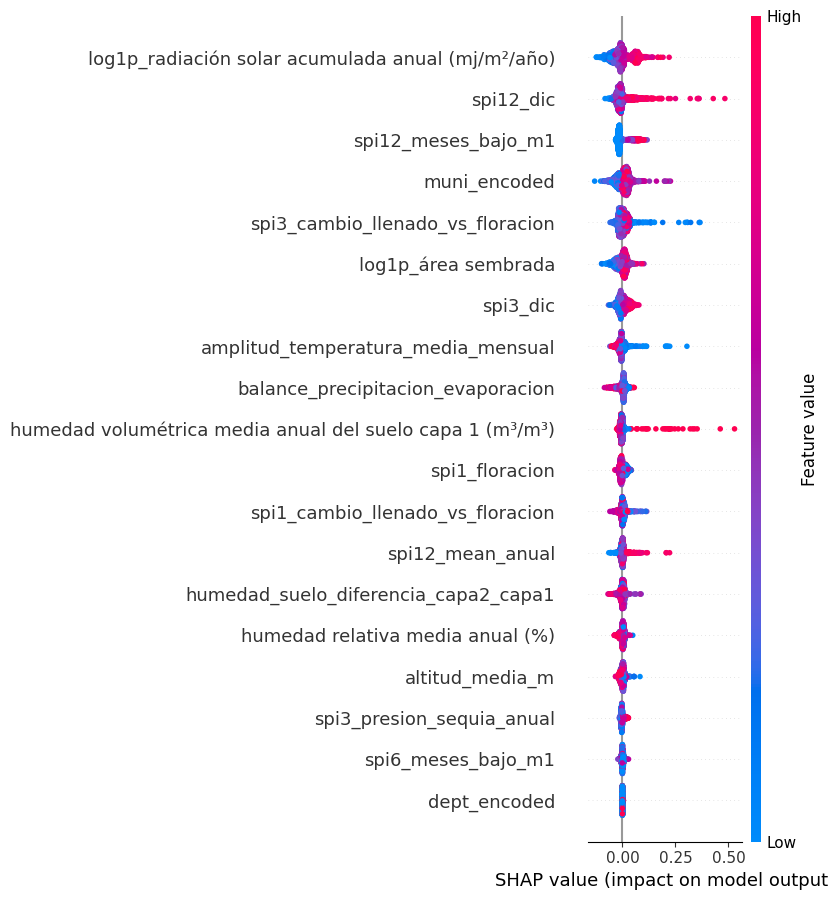

In [53]:
import shap
import numpy as np

# 1. Definimos una función de predicción simple que SHAP pueda llamar
# Esto evita que SHAP intente "leer" el modelo por dentro
def predict_fn(data):
    return xgb_model.predict(data)

# 2. Usamos KernelExplainer o simplemente Explainer con la función de predicción
# Usamos una muestra de X como 'masker' para que sea más rápido
X_summary = shap.sample(X, 100) # Resume los datos para acelerar el cálculo
explainer = shap.KernelExplainer(predict_fn, X_summary)

# 3. Calculamos los valores SHAP para el set de datos
# Advertencia: esto puede tardar un par de minutos según el tamaño de X
shap_values = explainer.shap_values(X)

# 4. Graficamos
shap.summary_plot(shap_values, X)

Revisando el SHAP del modelo encontramos Lo siguiente:  


**Las Variables Dominantes (El "Top 3")**  
- `log1p_radiación solar acumulada anual`: Es la variable más importante. La gráfica nos deja ver que valores altos (rojo) tienen un impacto positivo fuerte, mientras que la falta de luz (azul) castiga el rendimiento.

- `spi12_dic`: Que es el índice de precipitación a 12 meses acumulado a diciembre y es clave porque resume el estado hídrico de todo el año. Los puntos rojos hacia la derecha indican que años con buena humedad acumulada disparan el rendimiento.

- `spi12_meses_bajo_m1`: Cuenta cuántos meses el SPI estuvo por debajo de -1 (sequía moderada).

**Hallazgos Clave para el Seguro**
- `Humedad volumétrica del suelo (capa 1)`: El modelo otorga un impacto positivo muy alto cuando el suelo mantiene una buena reserva de agua. Para un seguro paramétrico, esto sugiere que la humedad del suelo podría ser un indicador incluso más preciso que la lluvia sola para determinar la salud del cultivo.

- `spi3_cambio_llenado_vs_floracion`: Esta variable captura la transición entre etapas fenológicas. Al estar dentro del Top 5, confirma que el café colombiano es sensible no solo al clima anual, sino a lo que ocurre específicamente entre la floración y el llenado del grano.

- `Altitud_media_m`: Aunque está más abajo, muestra un comportamiento interesante: valores bajos (azul) parecen tener impactos positivos en ciertos contextos, mientras que los rojos (altitud alta) pueden limitar el rendimiento por temperaturas más frías.

**Variables de Localización**  
`muni_encoded` tiene mucho más peso que `dept_encoded`. Lo que nos deja ver que el modelo está capturando variaciones a nivel microclima municipal y no solo tendencias departamentales genéricas

# Validación de Overfitting

Iniciando validación de Overfitting y RMSE (LOGO)...


'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root

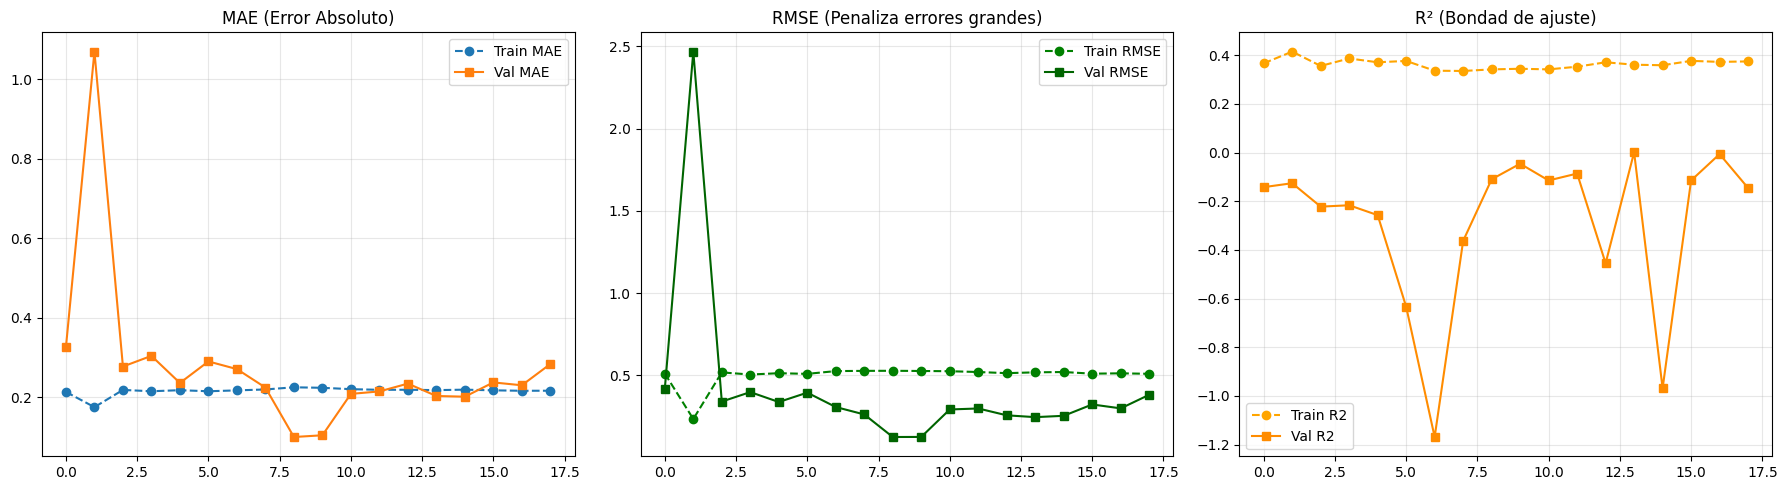

Métrica         | Train      | Validation | Gap       
--------------------------------------------------
MAE             | 0.216      | 0.279      | 0.063     
RMSE            | 0.502      | 0.419      | 0.083     
R2              | 0.363      | -0.288     | 0.651     


In [7]:
def evaluar_overfitting_completo(X, y, groups, params):
    logo = LeaveOneGroupOut()
    
    # Listas para almacenar métricas
    train_mae, val_mae = [], []
    train_rmse, val_rmse = [], []
    train_r2, val_r2 = [], []
    
    print("Iniciando validación de Overfitting y RMSE (LOGO)...")
    
    for train_index, test_index in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train)
        
        preds_train = model.predict(X_train)
        preds_val = model.predict(X_test)
        
        # Cálculo de métricas
        train_mae.append(mean_absolute_error(y_train, preds_train))
        val_mae.append(mean_absolute_error(y_test, preds_val))
        
        # RMSE: squared=False devuelve la raíz cuadrada directamente
        train_rmse.append(mean_squared_error(y_train, preds_train, squared=False))
        val_rmse.append(mean_squared_error(y_test, preds_val, squared=False))
        
        train_r2.append(r2_score(y_train, preds_train))
        val_r2.append(r2_score(y_test, preds_val))

    # --- Visualización ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Gráfico 1: MAE
    axes[0].plot(train_mae, label='Train MAE', marker='o', linestyle='--')
    axes[0].plot(val_mae, label='Val MAE', marker='s')
    axes[0].set_title('MAE (Error Absoluto)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Gráfico 2: RMSE
    axes[1].plot(train_rmse, label='Train RMSE', marker='o', linestyle='--', color='green')
    axes[1].plot(val_rmse, label='Val RMSE', marker='s', color='darkgreen')
    axes[1].set_title('RMSE (Penaliza errores grandes)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Gráfico 3: R2
    axes[2].plot(train_r2, label='Train R2', marker='o', linestyle='--', color='orange')
    axes[2].plot(val_r2, label='Val R2', marker='s', color='darkorange')
    axes[2].set_title('R² (Bondad de ajuste)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Resumen de métricas ---
    print(f"{'Métrica':<15} | {'Train':<10} | {'Validation':<10} | {'Gap':<10}")
    print("-" * 50)
    metrics = [
        ("MAE", np.mean(train_mae), np.mean(val_mae)),
        ("RMSE", np.mean(train_rmse), np.mean(val_rmse)),
        ("R2", np.mean(train_r2), np.mean(val_r2))
    ]
    for name, t, v in metrics:
        gap = abs(t - v)
        print(f"{name:<15} | {t:<10.3f} | {v:<10.3f} | {gap:<10.3f}")

# Ejecución
evaluar_overfitting_completo(X, y, data['anio'], final_params)